In [ ]:
#Import Libraries

In [6]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    log_loss,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [ ]:
#Read and inspect the data

In [8]:
# Checking dataset size and missing values
print("Dataset shape:", df.shape)
df.isnull().sum()

Dataset shape: (9105, 47)


age            0
death          0
sex            0
hospdead       0
slos           0
d.time         0
dzgroup        0
dzclass        0
num.co         0
edu         1634
income      2982
scoma          1
charges      172
totcst       888
totmcst     3475
avtisst       82
race          42
sps            1
aps            1
surv2m         1
surv6m         1
hday           0
diabetes       0
dementia       0
ca             0
prg2m       1649
prg6m       1633
dnr           30
dnrday        30
meanbp         1
wblc         212
hrt            1
resp           1
temp           1
pafi        2325
alb         3372
bili        2601
crea          67
sod            1
ph          2284
glucose     4500
bun         4352
urine       4862
adlp        5641
adls        2867
sfdm2       1400
adlsc          0
dtype: int64

In [23]:
# Reading the dataset
df = pd.read_csv("https://hbiostat.org/data/repo/support2csv.zip",compression="zip"
)
df.head()

,age,death,sex,hospdead,slos,d.time,dzgroup,dzclass,num.co,edu,...,crea,sod,ph,glucose,bun,urine,adlp,adls,sfdm2,adlsc
1,62.84998,0,male,0,5,2029,Lung Cancer,Cancer,0,11.0,...,1.199951,141.0,7.459961,NaN,NaN,NaN,7.0,7.0,NaN,7.0
2,60.33899,1,female,1,4,4,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,...,5.500000,132.0,7.250000,NaN,NaN,NaN,NaN,1.0,<2 mo. follow-up,1.0
3,52.74698,1,female,0,17,47,Cirrhosis,COPD/CHF/Cirrhosis,2,12.0,...,2.000000,134.0,7.459961,NaN,NaN,NaN,1.0,0.0,<2 mo. follow-up,0.0
4,42.38498,1,female,0,3,133,Lung Cancer,Cancer,2,11.0,...,0.799927,139.0,NaN,NaN,NaN,NaN,0.0,0.0,no(M2 and SIP pres),0.0
5,79.88495,0,female,0,16,2029,ARF/MOSF w/Sepsis,ARF/MOSF,1,NaN,...,0.799927,143.0,7.509766,NaN,NaN,NaN,NaN,2.0,no(M2 and SIP pres),2.0


In [ ]:
#Select the target and features

In [9]:
# Target: 0 = survived, 1 = died in hospital
y = df["hospdead"]

# Removing target and leakage features
remove_columns = [
    "death", "hospdead", "slos", "d.time",
    "charges", "totcst", "totmcst", "avtisst",
    "surv2m", "surv6m", "prg2m", "prg6m",
    "dnr", "dnrday", "sfdm2"
]

X = df.drop(columns=remove_columns, errors="ignore")

In [ ]:
#Visualize the target

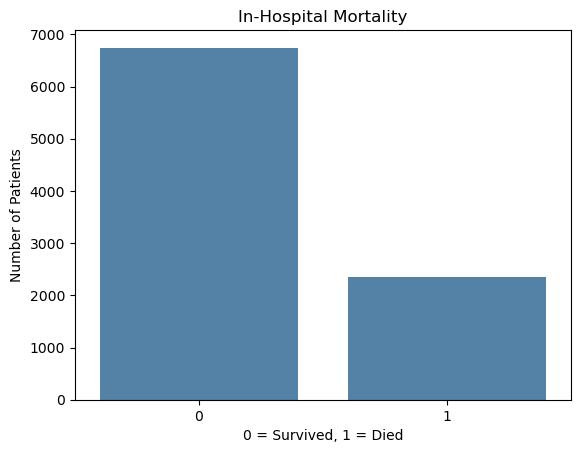

In [10]:
# Number of survived and deceased patients
sns.countplot(x=y, color="steelblue")

plt.title("In-Hospital Mortality")
plt.xlabel("0 = Survived, 1 = Died")
plt.ylabel("Number of Patients")
plt.show()

In [ ]:
#Split the dataset

In [11]:
# 70% training and 30% temporary data
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# 15% validation and 15% test data
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

# Create copies
X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (6373, 32)
Validation: (1366, 32)
Test: (1366, 32)


In [ ]:
#Handle missing values

In [13]:
# Identify numerical and categorical columns
numerical_columns = X_train.select_dtypes(
    include=np.number
).columns

categorical_columns = X_train.select_dtypes(
    exclude=np.number
).columns

In [14]:
# Replace missing numerical values with training median
for column in numerical_columns:
    median_value = X_train[column].median()
    
    X_train[column] = X_train[column].fillna(median_value)
    X_val[column] = X_val[column].fillna(median_value)
    X_test[column] = X_test[column].fillna(median_value)

In [15]:
# Replace missing categorical values with most common value
for column in categorical_columns:
    common_value = X_train[column].mode()[0]
    
    X_train[column] = X_train[column].fillna(common_value)
    X_val[column] = X_val[column].fillna(common_value)
    X_test[column] = X_test[column].fillna(common_value)

In [ ]:
#Convert categorical features

In [16]:
# One-hot encoding
X_train = pd.get_dummies(X_train, drop_first=True)
X_val = pd.get_dummies(X_val, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Give all datasets the same columns
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [ ]:
#Standardize numerical features

In [17]:
# Standardization
scaler = StandardScaler()

X_train[numerical_columns] = scaler.fit_transform(
    X_train[numerical_columns]
)

X_val[numerical_columns] = scaler.transform(
    X_val[numerical_columns]
)

X_test[numerical_columns] = scaler.transform(
    X_test[numerical_columns]
)

In [ ]:
#Train logistic regression

In [18]:
# Creating and training the model
model = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [ ]:
#Check validation performance

In [19]:
# Validation prediction
val_probability = model.predict_proba(X_val)[:, 1]

print(
    "Validation ROC-AUC:",
    round(roc_auc_score(y_val, val_probability), 3)
)

Validation ROC-AUC: 0.88


In [ ]:
#Test the model

In [20]:
# Test predictions
y_prediction = model.predict(X_test)
y_probability = model.predict_proba(X_test)[:, 1]

print("Accuracy:",
      round(accuracy_score(y_test, y_prediction), 3))

print("ROC-AUC:",
      round(roc_auc_score(y_test, y_probability), 3))

print("Logistic loss:",
      round(log_loss(y_test, y_probability), 3))

print(classification_report(y_test, y_prediction))

Accuracy: 0.775
ROC-AUC: 0.863
Logistic loss: 0.469
              precision    recall  f1-score   support

           0       0.91      0.77      0.84      1012
           1       0.55      0.77      0.64       354

    accuracy                           0.77      1366
   macro avg       0.73      0.77      0.74      1366
weighted avg       0.81      0.77      0.79      1366



In [ ]:
#Visualize model performance

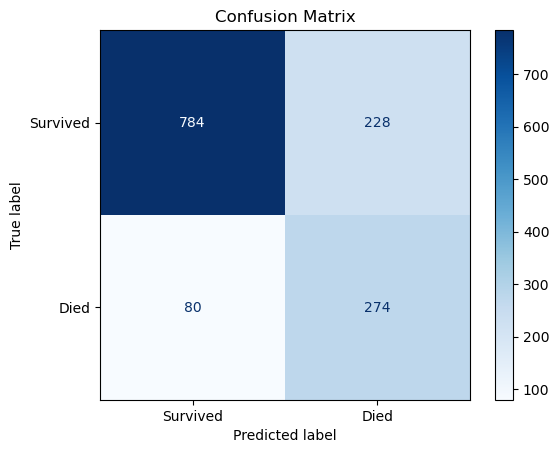

In [21]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_prediction,
    display_labels=["Survived", "Died"],
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

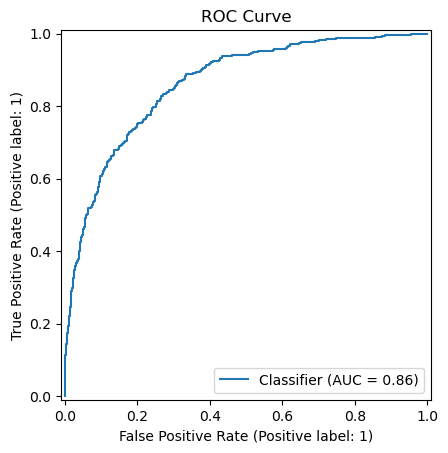

In [22]:
# ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    y_probability
)

plt.title("ROC Curve")
plt.show()